In [3]:
import pandas as pd
import boto3

In [4]:
s3_path = "s3://mgmt-599-final-project/gold/modeling/"

df = pd.read_parquet(
    s3_path,
    storage_options={"anon": False}
)

print(df.shape)
df.head()

(3917, 42)


,PLAYER_ID,PLAYER_NAME,SEASON,TEAM_ABBREVIATION,AGE,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,GP,MIN_PG,TOTAL_MINUTES,...,bref_dws,bref_ws,bref_ws_48,bref_obpm,bref_dbpm,bref_bpm,bref_vorp,total_salary,salary_cap,salary_pct_cap
0,203932,Aaron Gordon,2025-26,DEN,30.0,80.0,235.0,36,27.9,1004.4,...,0.7,3.2,0.153,2.9,-1.2,1.7,0.9,22841455,154647000,0.147701
1,1630598,Aaron Wiggins,2021-22,OKC,23.0,76.0,190.0,50,24.2,1210.0,...,0.8,1.2,0.048,-3.4,-0.9,-4.3,-0.7,1305761,112414000,0.011616
2,2405,Amar'e Stoudemire,2015-16,MIA,33.0,82.0,245.0,52,14.7,764.4,...,1.3,2.4,0.150,-1.3,0.6,-0.6,0.3,1499187,70000000,0.021417
3,1629599,Amir Coffey,2024-25,LAC,28.0,79.0,210.0,72,24.3,1749.6,...,1.7,4.0,0.111,-1.5,-0.2,-1.7,0.1,3938271,140588000,0.028013
4,203083,Andre Drummond,2019-20,CLE,26.0,82.0,279.0,57,33.0,1881.0,...,3.6,4.2,0.108,-0.1,1.1,0.9,1.4,27093018,109140000,0.248241


In [5]:
print(df.shape)
print(df.columns.tolist())
df.info()

(3917, 42)
['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'TEAM_ABBREVIATION', 'AGE', 'PLAYER_HEIGHT_INCHES', 'PLAYER_WEIGHT', 'GP', 'MIN_PG', 'TOTAL_MINUTES', 'PTS_PG', 'REB_PG', 'AST_PG', 'STL_PG', 'BLK_PG', 'TOV_PG', 'FG_PCT_PG', 'FG3_PCT_PG', 'FG3M_PG', 'FTA_PG', 'FT_PCT_PG', 'TS_PCT', 'USG_PCT', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'AST_PCT', 'REB_PCT', 'PIE', 'E_TOV_PCT', 'bref_per', 'bref_ows', 'bref_dws', 'bref_ws', 'bref_ws_48', 'bref_obpm', 'bref_dbpm', 'bref_bpm', 'bref_vorp', 'total_salary', 'salary_cap', 'salary_pct_cap']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3917 entries, 0 to 3916
Data columns (total 42 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PLAYER_ID             3917 non-null   int32  
 1   PLAYER_NAME           3917 non-null   object 
 2   SEASON                3917 non-null   object 
 3   TEAM_ABBREVIATION     3917 non-null   object 
 4   AGE                   3917 non-null   float6

In [4]:
df["SEASON"].value_counts().sort_index()

SEASON
2015-16    346
2016-17    351
2017-18    351
2018-19    357
2019-20    333
2020-21    360
2021-22    373
2022-23    366
2023-24    359
2024-25    359
2025-26    362
Name: count, dtype: int64

In [6]:
# Final modeling-data sanity checks

print("Shape:", df.shape)
print("Duplicate player-seasons:",
      df.duplicated(subset=["PLAYER_ID", "SEASON"]).sum())

print("Missing salary_pct_cap:",
      df["salary_pct_cap"].isna().sum())

print("Seasons:")
print(df["SEASON"].value_counts().sort_index())

print("\nSalary % of cap:")
print(df["salary_pct_cap"].describe())

Shape: (3917, 42)
Duplicate player-seasons: 0
Missing salary_pct_cap: 0
Seasons:
SEASON
2015-16    346
2016-17    351
2017-18    351
2018-19    357
2019-20    333
2020-21    360
2021-22    373
2022-23    366
2023-24    359
2024-25    359
2025-26    362
Name: count, dtype: int64

Salary % of cap:
count    3917.000000
mean        0.085863
std         0.086047
min         0.000729
25%         0.021363
50%         0.050846
75%         0.122707
max         0.407253
Name: salary_pct_cap, dtype: float64


In [7]:
df["AGE_SQ"] = df["AGE"] **2

In [8]:
baseline_features = [
    "AGE",
    "AGE_SQ",
    "MIN_PG",
    "PTS_PG",
    "REB_PG",
    "AST_PG",
    "STL_PG",
    "BLK_PG",
    "TOV_PG",
    "TS_PCT",
    "USG_PCT"
]

In [9]:
target = "salary_pct_cap"

In [10]:
train = df[df["SEASON"].isin([
    "2015-16",
    "2016-17",
    "2017-18",
    "2018-19",
    "2019-20",
    "2020-21",
    "2021-22",
    "2022-23"
])].copy()

validation = df[df["SEASON"] == "2023-24"].copy()

test = df[df["SEASON"] == "2024-25"].copy()

current = df[df["SEASON"] == "2025-26"].copy()

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)
print("Current:", current.shape)

Train: (2837, 43)
Validation: (359, 43)
Test: (359, 43)
Current: (362, 43)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

X_train = train[baseline_features]
y_train = train[target]

X_val = validation[baseline_features]
y_val = validation[target]

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

val_pred = baseline_model.predict(X_val)

print("Validation R²:", r2_score(y_val, val_pred))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_pred)))
print("Validation MAE:", mean_absolute_error(y_val, val_pred))

Validation R²: 0.665513204581038
Validation RMSE: 0.05079670293137226
Validation MAE: 0.03874842235831955


In [12]:
coef_table = pd.DataFrame({
    "feature": baseline_features,
    "coefficient": baseline_model.coef_
}).sort_values(
    "coefficient",
    ascending=False
)

coef_table

,feature,coefficient
0,AGE,0.028027
7,BLK_PG,0.013097
3,PTS_PG,0.011556
5,AST_PG,0.007443
4,REB_PG,0.006555
1,AGE_SQ,-0.000377
2,MIN_PG,-0.002000
6,STL_PG,-0.002414
8,TOV_PG,-0.003045
9,TS_PCT,-0.237285


In [13]:
import statsmodels.api as sm

X_train_sm = train[baseline_features]
X_train_sm = sm.add_constant(X_train_sm)

ols_model = sm.OLS(y_train, X_train_sm).fit(cov_type="HC3")

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:         salary_pct_cap   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     315.4
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:46:33   Log-Likelihood:                 4304.3
No. Observations:                2837   AIC:                            -8585.
Df Residuals:                    2825   BIC:                            -8513.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3137      0.041     -7.727      0.0

In [14]:
height_features = baseline_features + ["PLAYER_HEIGHT_INCHES"]

X_height = sm.add_constant(train[height_features])

height_model = sm.OLS(
    y_train,
    X_height
).fit(cov_type="HC3")

print(height_model.summary())

                            OLS Regression Results                            
Dep. Variable:         salary_pct_cap   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     301.0
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:46:35   Log-Likelihood:                 4325.2
No. Observations:                2837   AIC:                            -8624.
Df Residuals:                    2824   BIC:                            -8547.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.5609 

In [15]:
height_model_sk = LinearRegression()

height_model_sk.fit(
    train[height_features],
    y_train
)

height_val_pred = height_model_sk.predict(
    validation[height_features]
)

print("Baseline validation R²:",
      r2_score(y_val, val_pred))
print("Height validation R²:",
      r2_score(y_val, height_val_pred))

print("Baseline validation RMSE:",
      np.sqrt(mean_squared_error(y_val, val_pred)))
print("Height validation RMSE:",
      np.sqrt(mean_squared_error(y_val, height_val_pred)))

print("Baseline validation MAE:",
      mean_absolute_error(y_val, val_pred))
print("Height validation MAE:",
      mean_absolute_error(y_val, height_val_pred))

Baseline validation R²: 0.665513204581038
Height validation R²: 0.6626136249257273
Baseline validation RMSE: 0.05079670293137226
Height validation RMSE: 0.05101639958564689
Baseline validation MAE: 0.03874842235831955
Height validation MAE: 0.03894115688828562


In [16]:
mean_prediction = np.repeat(y_train.mean(), len(y_val))

print("Mean baseline RMSE:",
      np.sqrt(mean_squared_error(y_val, mean_prediction)))
print("Mean baseline MAE:",
      mean_absolute_error(y_val, mean_prediction))

Mean baseline RMSE: 0.08794408589586686
Mean baseline MAE: 0.06750420528965839


In [17]:
advanced_features = [
    "AGE",
    "AGE_SQ",
    "MIN_PG",
    "USG_PCT",
    "TS_PCT",
    "bref_ws_48",
    "bref_bpm",
    "bref_vorp"
]

In [18]:
advanced_model = LinearRegression()

advanced_model.fit(
    train[advanced_features],
    y_train
)

advanced_val_pred = advanced_model.predict(
    validation[advanced_features]
)

advanced_r2 = r2_score(y_val, advanced_val_pred)
advanced_rmse = np.sqrt(mean_squared_error(y_val, advanced_val_pred))
advanced_mae = mean_absolute_error(y_val, advanced_val_pred)

print("Advanced validation R²:", advanced_r2)
print("Advanced validation RMSE:", advanced_rmse)
print("Advanced validation MAE:", advanced_mae)

Advanced validation R²: 0.6482222472007715
Advanced validation RMSE: 0.05209310216850491
Advanced validation MAE: 0.03978063759164172


In [19]:
comparison = pd.DataFrame({
    "Model": ["Naive Mean", "Box Score OLS", "Advanced OLS"],
    "R2": [
        np.nan,
        r2_score(y_val, val_pred),
        advanced_r2
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, mean_prediction)),
        np.sqrt(mean_squared_error(y_val, val_pred)),
        advanced_rmse
    ],
    "MAE": [
        mean_absolute_error(y_val, mean_prediction),
        mean_absolute_error(y_val, val_pred),
        advanced_mae
    ]
})

comparison

,Model,R2,RMSE,MAE
0,Naive Mean,NaN,0.087944,0.067504
1,Box Score OLS,0.665513,0.050797,0.038748
2,Advanced OLS,0.648222,0.052093,0.039781


In [20]:
combined_features = baseline_features + [
    "bref_ws_48",
    "bref_bpm",
    "bref_vorp"
]

combined_model = LinearRegression()

combined_model.fit(
    train[combined_features],
    y_train
)

combined_val_pred = combined_model.predict(
    validation[combined_features]
)

combined_r2 = r2_score(y_val, combined_val_pred)
combined_rmse = np.sqrt(
    mean_squared_error(y_val, combined_val_pred)
)
combined_mae = mean_absolute_error(
    y_val, combined_val_pred
)

print("Combined validation R²:", combined_r2)
print("Combined validation RMSE:", combined_rmse)
print("Combined validation MAE:", combined_mae)

Combined validation R²: 0.6668413739833838
Combined validation RMSE: 0.050695751661583785
Combined validation MAE: 0.038694709930226764


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Mean",
        "Box Score OLS",
        "Advanced OLS",
        "Combined OLS"
    ],
    "R2": [
        np.nan,
        r2_score(y_val, val_pred),
        advanced_r2,
        combined_r2
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, mean_prediction)),
        np.sqrt(mean_squared_error(y_val, val_pred)),
        advanced_rmse,
        combined_rmse
    ],
    "MAE": [
        mean_absolute_error(y_val, mean_prediction),
        mean_absolute_error(y_val, val_pred),
        advanced_mae,
        combined_mae
    ]
})

comparison

,Model,R2,RMSE,MAE
0,Naive Mean,NaN,0.087944,0.067504
1,Box Score OLS,0.665513,0.050797,0.038748
2,Advanced OLS,0.648222,0.052093,0.039781
3,Combined OLS,0.666841,0.050696,0.038695


In [22]:
rf_features = [
    "AGE",
    "PLAYER_HEIGHT_INCHES",
    "PLAYER_WEIGHT",
    "GP",
    "MIN_PG",
    "TOTAL_MINUTES",
    "PTS_PG",
    "REB_PG",
    "AST_PG",
    "STL_PG",
    "BLK_PG",
    "TOV_PG",
    "FG_PCT_PG",
    "FG3_PCT_PG",
    "FG3M_PG",
    "FTA_PG",
    "FT_PCT_PG",
    "TS_PCT",
    "USG_PCT",
    "OFF_RATING",
    "DEF_RATING",
    "NET_RATING",
    "AST_PCT",
    "REB_PCT",
    "PIE",
    "E_TOV_PCT",
    "bref_per",
    "bref_ows",
    "bref_dws",
    "bref_ws",
    "bref_ws_48",
    "bref_obpm",
    "bref_dbpm",
    "bref_bpm",
    "bref_vorp"
]

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    train[rf_features],
    y_train
)

rf_val_pred = rf_model.predict(
    validation[rf_features]
)

rf_r2 = r2_score(y_val, rf_val_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_mae = mean_absolute_error(y_val, rf_val_pred)

print("Random Forest validation R²:", rf_r2)
print("Random Forest validation RMSE:", rf_rmse)
print("Random Forest validation MAE:", rf_mae)

Random Forest validation R²: 0.7066233821646829
Random Forest validation RMSE: 0.04757280775288761
Random Forest validation MAE: 0.03480914560824777


In [24]:
rf_importance = pd.DataFrame({
    "feature": rf_features,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

rf_importance.head(15)

,feature,importance
0,AGE,0.115388
4,MIN_PG,0.110452
6,PTS_PG,0.100331
31,bref_obpm,0.065686
15,FTA_PG,0.064636
34,bref_vorp,0.051575
18,USG_PCT,0.045605
24,PIE,0.038582
11,TOV_PG,0.037982
33,bref_bpm,0.034423


In [25]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gb_model.fit(
    train[rf_features],
    y_train
)

gb_val_pred = gb_model.predict(
    validation[rf_features]
)

gb_r2 = r2_score(y_val, gb_val_pred)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_val_pred))
gb_mae = mean_absolute_error(y_val, gb_val_pred)

print("Gradient Boosting validation R²:", gb_r2)
print("Gradient Boosting validation RMSE:", gb_rmse)
print("Gradient Boosting validation MAE:", gb_mae)

Gradient Boosting validation R²: 0.7649534422048907
Gradient Boosting validation RMSE: 0.04258169875791907
Gradient Boosting validation MAE: 0.029483995574250365


In [26]:
import xgboost as xgb
print(xgb.__version__)

2.1.4


In [27]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    train[rf_features],
    y_train
)

xgb_val_pred = xgb_model.predict(
    validation[rf_features]
)

xgb_r2 = r2_score(y_val, xgb_val_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_mae = mean_absolute_error(y_val, xgb_val_pred)

print("XGBoost validation R²:", xgb_r2)
print("XGBoost validation RMSE:", xgb_rmse)
print("XGBoost validation MAE:", xgb_mae)

XGBoost validation R²: 0.7738764425417768
XGBoost validation RMSE: 0.041765620711320645
XGBoost validation MAE: 0.029209570632720738


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Mean",
        "Box Score OLS",
        "Advanced OLS",
        "Combined OLS",
        "Random Forest",
        "Hist Gradient Boosting",
        "XGBoost"
    ],
    "R2": [
        np.nan,
        r2_score(y_val, val_pred),
        advanced_r2,
        combined_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, mean_prediction)),
        np.sqrt(mean_squared_error(y_val, val_pred)),
        advanced_rmse,
        combined_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse
    ],
    "MAE": [
        mean_absolute_error(y_val, mean_prediction),
        mean_absolute_error(y_val, val_pred),
        advanced_mae,
        combined_mae,
        rf_mae,
        gb_mae,
        xgb_mae
    ]
})

comparison

,Model,R2,RMSE,MAE
0,Naive Mean,NaN,0.087944,0.067504
1,Box Score OLS,0.665513,0.050797,0.038748
2,Advanced OLS,0.648222,0.052093,0.039781
3,Combined OLS,0.666841,0.050696,0.038695
4,Random Forest,0.706623,0.047573,0.034809
5,Hist Gradient Boosting,0.764953,0.042582,0.029484
6,XGBoost,0.773876,0.041766,0.029210


In [29]:
tuning_results = []

configs = [
    (0.05, 300, 2),
    (0.05, 300, 3),
    (0.05, 300, 4),
    (0.03, 500, 2),
    (0.03, 500, 3),
    (0.03, 500, 4),
    (0.02, 750, 2),
    (0.02, 750, 3),
    (0.02, 750, 4),
]

for learning_rate, n_estimators, max_depth in configs:

    model_temp = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model_temp.fit(train[rf_features], y_train)

    pred_temp = model_temp.predict(validation[rf_features])

    tuning_results.append({
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "R2": r2_score(y_val, pred_temp),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred_temp)),
        "MAE": mean_absolute_error(y_val, pred_temp)
    })

tuning_results = pd.DataFrame(tuning_results)

tuning_results.sort_values("RMSE")

,learning_rate,n_estimators,max_depth,R2,RMSE,MAE
7,0.02,750,3,0.773890,0.041764,0.028989
4,0.03,500,3,0.773876,0.041766,0.029210
6,0.02,750,2,0.770926,0.042037,0.029619
5,0.03,500,4,0.770924,0.042037,0.029137
8,0.02,750,4,0.769903,0.042131,0.028986
1,0.05,300,3,0.769594,0.042159,0.029417
3,0.03,500,2,0.769088,0.042206,0.029827
0,0.05,300,2,0.765713,0.042513,0.029984
2,0.05,300,4,0.764740,0.042601,0.029611


In [30]:
df.groupby("SEASON").size()

SEASON
2015-16    346
2016-17    351
2017-18    351
2018-19    357
2019-20    333
2020-21    360
2021-22    373
2022-23    366
2023-24    359
2024-25    359
2025-26    362
dtype: int64

In [31]:
test = df[df["SEASON"] == "2024-25"].copy()

X_test = test[rf_features]
y_test = test["salary_pct_cap"]

print("Test observations:", len(test))

Test observations: 359


In [34]:
params = xgb_model.get_params()

for p in [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_alpha",
    "reg_lambda"
]:
    print(p, "=", params[p])

n_estimators = 500
learning_rate = 0.03
max_depth = 3
min_child_weight = 5
subsample = 0.8
colsample_bytree = 0.8
reg_alpha = 0.0
reg_lambda = 1.0


In [32]:
xgb_test_pred = xgb_model.predict(X_test)

xgb_test_r2 = r2_score(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_test_pred)
)
xgb_test_mae = mean_absolute_error(
    y_test, xgb_test_pred
)

print("FINAL TEST RESULTS — 2024-25")
print("R²:", xgb_test_r2)
print("RMSE:", xgb_test_rmse)
print("MAE:", xgb_test_mae)

FINAL TEST RESULTS — 2024-25
R²: 0.7278187907099085
RMSE: 0.04942324846475749
MAE: 0.035092264602504454


In [35]:
test_results = []

models = [
    ("Box Score OLS", baseline_model, baseline_features),
    ("Random Forest", rf_model, rf_features),
    ("Hist Gradient Boosting", gb_model, rf_features),
    ("XGBoost", xgb_model, rf_features)
]

for name, fitted_model, features in models:

    pred = fitted_model.predict(test[features])

    test_results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

test_comparison = pd.DataFrame(test_results)
test_comparison.sort_values("RMSE")

,Model,R2,RMSE,MAE
3,XGBoost,0.727819,0.049423,0.035092
2,Hist Gradient Boosting,0.719112,0.050208,0.035526
1,Random Forest,0.657054,0.055477,0.040590
0,Box Score OLS,0.628444,0.057745,0.043647


In [36]:
# Train on all completed historical seasons through 2024-25
final_train = df[df["SEASON"] != "2025-26"].copy()

# Current season to evaluate for contract value
current = df[df["SEASON"] == "2025-26"].copy()

print("Final training rows:", len(final_train))
print("2025-26 rows:", len(current))

Final training rows: 3555
2025-26 rows: 362


In [37]:
final_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    final_train[rf_features],
    final_train["salary_pct_cap"]
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
current["pred_salary_pct_cap"] = final_xgb.predict(
    current[rf_features]
)

In [39]:
current["value_gap"] = (
    current["pred_salary_pct_cap"]
    - current["salary_pct_cap"]
)

In [40]:
bargains = current[
    [
        "PLAYER_NAME",
        "TEAM_ABBREVIATION",
        "AGE",
        "PTS_PG",
        "MIN_PG",
        "salary_pct_cap",
        "pred_salary_pct_cap",
        "value_gap"
    ]
].sort_values(
    "value_gap",
    ascending=False
)

overpaid = current[
    [
        "PLAYER_NAME",
        "TEAM_ABBREVIATION",
        "AGE",
        "PTS_PG",
        "MIN_PG",
        "salary_pct_cap",
        "pred_salary_pct_cap",
        "value_gap"
    ]
].sort_values(
    "value_gap",
    ascending=True
)

print("TOP BARGAINS")
display(bargains.head(15))

print("MOST OVERPAID RELATIVE TO PRODUCTION")
display(overpaid.head(15))

TOP BARGAINS


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,PTS_PG,MIN_PG,salary_pct_cap,pred_salary_pct_cap,value_gap
2917,Russell Westbrook,SAC,37.0,15.2,28.9,0.023500,0.206585,0.183086
2763,Deni Avdija,POR,25.0,24.2,33.3,0.092954,0.253102,0.160148
1224,Austin Reaves,LAL,28.0,23.3,34.5,0.090125,0.243961,0.153836
2107,Kevin Porter Jr.,MIL,26.0,17.4,33.2,0.033198,0.178993,0.145795
1398,Payton Pritchard,BOS,28.0,17.0,32.3,0.046765,0.162933,0.116167
2852,Kelly Oubre Jr.,PHI,30.0,14.1,31.5,0.054202,0.165807,0.111605
1790,Jalen Williams,OKC,25.0,17.1,28.4,0.042555,0.151299,0.108744
201,Saddiq Bey,NOP,27.0,17.7,31.2,0.040284,0.147820,0.107536
943,Toumani Camara,POR,26.0,13.4,33.3,0.014366,0.112820,0.098454
2157,Norman Powell,MIA,33.0,21.7,29.6,0.132448,0.224269,0.091821


MOST OVERPAID RELATIVE TO PRODUCTION


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,PTS_PG,MIN_PG,salary_pct_cap,pred_salary_pct_cap,value_gap
827,Jalen Suggs,ORL,25.0,13.8,27.6,0.226322,0.085503,-0.140819
3201,Zach LaVine,SAC,31.0,19.2,31.4,0.307149,0.184146,-0.123003
1213,Alperen Sengun,HOU,23.0,20.4,33.3,0.219500,0.098172,-0.121327
1351,Khris Middleton,DAL,34.0,10.2,22.8,0.226881,0.106667,-0.120214
3289,Ja Morant,MEM,26.0,19.5,28.4,0.255072,0.142664,-0.112408
2360,Jordan Poole,NOP,27.0,13.4,23.9,0.205941,0.095278,-0.110663
3022,Evan Mobley,CLE,25.0,18.2,31.9,0.300000,0.191616,-0.108384
2001,Deandre Ayton,LAL,27.0,12.5,27.2,0.217623,0.112972,-0.104651
1509,Desmond Bane,ORL,28.0,20.1,33.6,0.237481,0.134276,-0.103205
3772,Jonathan Kuminga,ATL,23.0,12.2,23.1,0.145493,0.042357,-0.103135


In [41]:
final_r2 = r2_score(
    current["salary_pct_cap"],
    current["pred_salary_pct_cap"]
)

final_rmse = np.sqrt(
    mean_squared_error(
        current["salary_pct_cap"],
        current["pred_salary_pct_cap"]
    )
)

final_mae = mean_absolute_error(
    current["salary_pct_cap"],
    current["pred_salary_pct_cap"]
)

print("2025-26 R²:", final_r2)
print("2025-26 RMSE:", final_rmse)
print("2025-26 MAE:", final_mae)

2025-26 R²: 0.7562421167818867
2025-26 RMSE: 0.04512749673693336
2025-26 MAE: 0.03270271082100946


In [42]:
qualified = current[current["TOTAL_MINUTES"] >= 1000].copy()

qualified_bargains = qualified.sort_values(
    "value_gap", ascending=False
)

qualified_overpaid = qualified.sort_values(
    "value_gap", ascending=True
)

cols = [
    "PLAYER_NAME",
    "TEAM_ABBREVIATION",
    "AGE",
    "GP",
    "TOTAL_MINUTES",
    "PTS_PG",
    "salary_pct_cap",
    "pred_salary_pct_cap",
    "value_gap"
]

print("TOP QUALIFIED BARGAINS")
display(qualified_bargains[cols].head(15))

print("MOST OVERPAID — QUALIFIED")
display(qualified_overpaid[cols].head(15))

TOP QUALIFIED BARGAINS


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,TOTAL_MINUTES,PTS_PG,salary_pct_cap,pred_salary_pct_cap,value_gap
2917,Russell Westbrook,SAC,37.0,64,1849.6,15.2,0.023500,0.206585,0.183086
2763,Deni Avdija,POR,25.0,66,2197.8,24.2,0.092954,0.253102,0.160148
1224,Austin Reaves,LAL,28.0,51,1759.5,23.3,0.090125,0.243961,0.153836
2107,Kevin Porter Jr.,MIL,26.0,38,1261.6,17.4,0.033198,0.178993,0.145795
1398,Payton Pritchard,BOS,28.0,79,2551.7,17.0,0.046765,0.162933,0.116167
2852,Kelly Oubre Jr.,PHI,30.0,50,1575.0,14.1,0.054202,0.165807,0.111605
201,Saddiq Bey,NOP,27.0,72,2246.4,17.7,0.040284,0.147820,0.107536
943,Toumani Camara,POR,26.0,82,2730.6,13.4,0.014366,0.112820,0.098454
2157,Norman Powell,MIA,33.0,58,1716.8,21.7,0.132448,0.224269,0.091821
345,Jock Landale,ATL,30.0,68,1502.8,10.6,0.015917,0.105226,0.089310


MOST OVERPAID — QUALIFIED


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,TOTAL_MINUTES,PTS_PG,salary_pct_cap,pred_salary_pct_cap,value_gap
827,Jalen Suggs,ORL,25.0,57,1573.2,13.8,0.226322,0.085503,-0.140819
3201,Zach LaVine,SAC,31.0,39,1224.6,19.2,0.307149,0.184146,-0.123003
1213,Alperen Sengun,HOU,23.0,72,2397.6,20.4,0.219500,0.098172,-0.121327
1351,Khris Middleton,DAL,34.0,63,1436.4,10.2,0.226881,0.106667,-0.120214
3022,Evan Mobley,CLE,25.0,65,2073.5,18.2,0.300000,0.191616,-0.108384
2001,Deandre Ayton,LAL,27.0,72,1958.4,12.5,0.217623,0.112972,-0.104651
1509,Desmond Bane,ORL,28.0,82,2755.2,20.1,0.237481,0.134276,-0.103205
859,Karl-Anthony Towns,NYK,30.0,75,2325.0,20.1,0.343636,0.246054,-0.097582
1412,Scottie Barnes,TOR,24.0,80,2680.0,18.1,0.250000,0.161686,-0.088314
190,Patrick Williams,CHI,24.0,72,1476.0,7.0,0.116394,0.030307,-0.086087


In [43]:
current.head()

,PLAYER_ID,PLAYER_NAME,SEASON,TEAM_ABBREVIATION,AGE,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,GP,MIN_PG,TOTAL_MINUTES,...,bref_obpm,bref_dbpm,bref_bpm,bref_vorp,total_salary,salary_cap,salary_pct_cap,AGE_SQ,pred_salary_pct_cap,value_gap
0,203932,Aaron Gordon,2025-26,DEN,30.0,80.0,235.0,36,27.9,1004.4,...,2.9,-1.2,1.7,0.9,22841455,154647000,0.147701,900.0,0.191966,0.044266
18,1642267,Bub Carrington,2025-26,WAS,20.0,76.0,190.0,82,27.7,2271.4,...,-2.2,-2.5,-4.7,-1.6,4677600,154647000,0.030247,400.0,0.021513,-0.008734
20,1628997,Caleb Martin,2025-26,DAL,30.0,77.0,205.0,58,14.8,858.4,...,-4.0,1.7,-2.2,0.0,9594044,154647000,0.062038,900.0,0.043956,-0.018082
21,1630560,Cam Thomas,2025-26,MIL,24.0,75.0,210.0,42,21.0,882.0,...,-1.2,-3.9,-5.2,-0.7,6898538,154647000,0.044608,576.0,0.067107,0.022499
30,1642874,Danny Wolf,2025-26,BKN,22.0,83.0,250.0,57,20.8,1185.6,...,-2.2,-0.3,-2.5,-0.2,2801280,154647000,0.018114,484.0,0.045759,0.027645


In [44]:
scored_output = current.copy()

scored_output = scored_output.drop(
    columns=["AGE_SQ"],
    errors="ignore"
)

In [45]:
scored_output.columns.tolist()

['PLAYER_ID',
 'PLAYER_NAME',
 'SEASON',
 'TEAM_ABBREVIATION',
 'AGE',
 'PLAYER_HEIGHT_INCHES',
 'PLAYER_WEIGHT',
 'GP',
 'MIN_PG',
 'TOTAL_MINUTES',
 'PTS_PG',
 'REB_PG',
 'AST_PG',
 'STL_PG',
 'BLK_PG',
 'TOV_PG',
 'FG_PCT_PG',
 'FG3_PCT_PG',
 'FG3M_PG',
 'FTA_PG',
 'FT_PCT_PG',
 'TS_PCT',
 'USG_PCT',
 'OFF_RATING',
 'DEF_RATING',
 'NET_RATING',
 'AST_PCT',
 'REB_PCT',
 'PIE',
 'E_TOV_PCT',
 'bref_per',
 'bref_ows',
 'bref_dws',
 'bref_ws',
 'bref_ws_48',
 'bref_obpm',
 'bref_dbpm',
 'bref_bpm',
 'bref_vorp',
 'total_salary',
 'salary_cap',
 'salary_pct_cap',
 'pred_salary_pct_cap',
 'value_gap']

In [46]:
scored_output.to_parquet(
    "s3://mgmt-599-final-project/gold/player_value_scored/",
    index=False
)

In [47]:
scored_output.dtypes

PLAYER_ID                 int32
PLAYER_NAME              object
SEASON                   object
TEAM_ABBREVIATION        object
AGE                     float64
PLAYER_HEIGHT_INCHES    float64
PLAYER_WEIGHT           float64
GP                        int32
MIN_PG                  float64
TOTAL_MINUTES           float64
PTS_PG                  float64
REB_PG                  float64
AST_PG                  float64
STL_PG                  float64
BLK_PG                  float64
TOV_PG                  float64
FG_PCT_PG               float64
FG3_PCT_PG              float64
FG3M_PG                 float64
FTA_PG                  float64
FT_PCT_PG               float64
TS_PCT                  float64
USG_PCT                 float64
OFF_RATING              float64
DEF_RATING              float64
NET_RATING              float64
AST_PCT                 float64
REB_PCT                 float64
PIE                     float64
E_TOV_PCT               float64
bref_per                float64
bref_ows

In [48]:
scored_output.to_parquet(
    "player_value_scored.parquet",
    index=False
)

In [49]:
s3 = boto3.client("s3")

s3.upload_file(
    "player_value_scored.parquet",
    "mgmt-599-final-project",
    "gold/player_value_scored/player_value_scored.parquet"
)

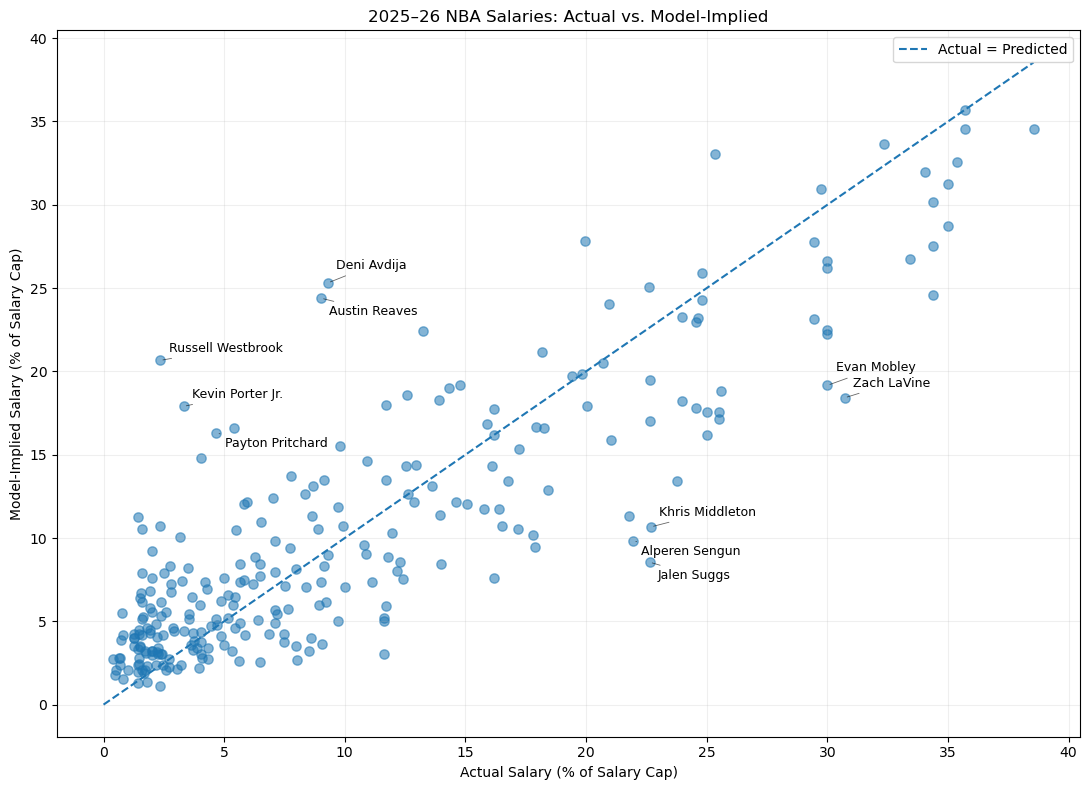

In [52]:
import matplotlib.pyplot as plt

# Keep players with at least 1,000 minutes
qualified = current[current["TOTAL_MINUTES"] >= 1000].copy()

qualified["actual_pct"] = qualified["salary_pct_cap"] * 100
qualified["predicted_pct"] = qualified["pred_salary_pct_cap"] * 100

top_bargains = qualified.nlargest(5, "value_gap")
top_overpaid = qualified.nsmallest(5, "value_gap")
label_players = pd.concat([top_bargains, top_overpaid])

# Hand-tuned label offsets: (x offset, y offset)
offsets = {
    "Russell Westbrook": (6, 6),
    "Deni Avdija": (6, 10),
    "Austin Reaves": (6, -12),
    "Kevin Porter Jr.": (6, 6),
    "Payton Pritchard": (6, -10),
    "Jalen Suggs": (6, -12),
    "Zach LaVine": (6, 8),
    "Alperen Sengun": (6, -10),
    "Khris Middleton": (6, 8),
    "Evan Mobley": (6, 10),
}

plt.figure(figsize=(11, 8))

plt.scatter(
    qualified["actual_pct"],
    qualified["predicted_pct"],
    alpha=0.55,
    s=45
)

max_val = max(
    qualified["actual_pct"].max(),
    qualified["predicted_pct"].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=1.5,
    label="Actual = Predicted"
)

for _, row in label_players.iterrows():
    xoff, yoff = offsets[row["PLAYER_NAME"]]

    plt.annotate(
        row["PLAYER_NAME"],
        (row["actual_pct"], row["predicted_pct"]),
        xytext=(xoff, yoff),
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.6,
            alpha=0.6
        )
    )

plt.xlabel("Actual Salary (% of Salary Cap)")
plt.ylabel("Model-Implied Salary (% of Salary Cap)")
plt.title("2025–26 NBA Salaries: Actual vs. Model-Implied")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

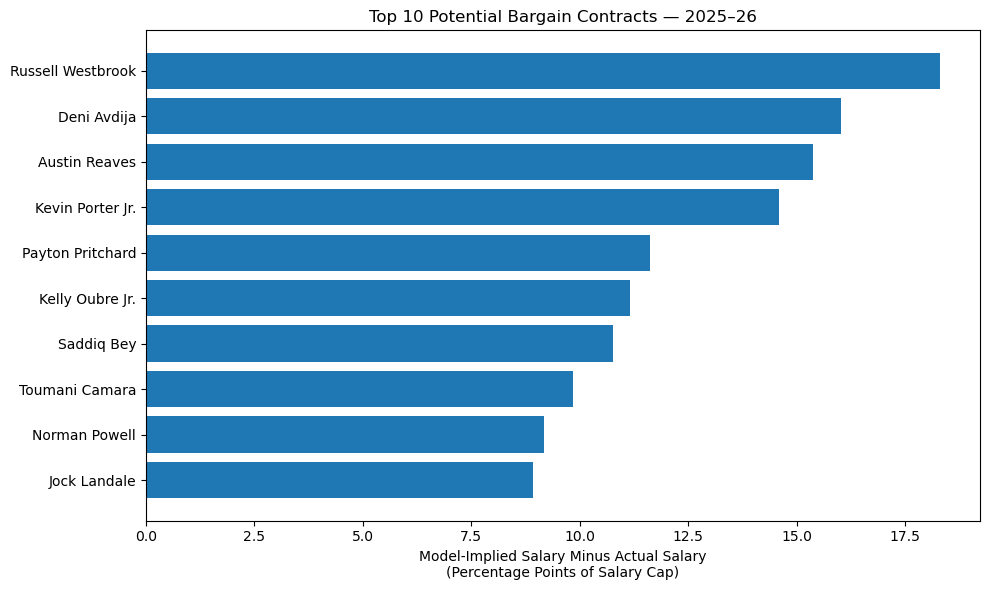

In [53]:
qualified = current[current["TOTAL_MINUTES"] >= 1000].copy()

top10_bargains = (
    qualified
    .nlargest(10, "value_gap")
    .sort_values("value_gap", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_bargains["PLAYER_NAME"],
    top10_bargains["value_gap"] * 100
)

plt.xlabel("Model-Implied Salary Minus Actual Salary\n(Percentage Points of Salary Cap)")
plt.title("Top 10 Potential Bargain Contracts — 2025–26")

plt.tight_layout()
plt.show()

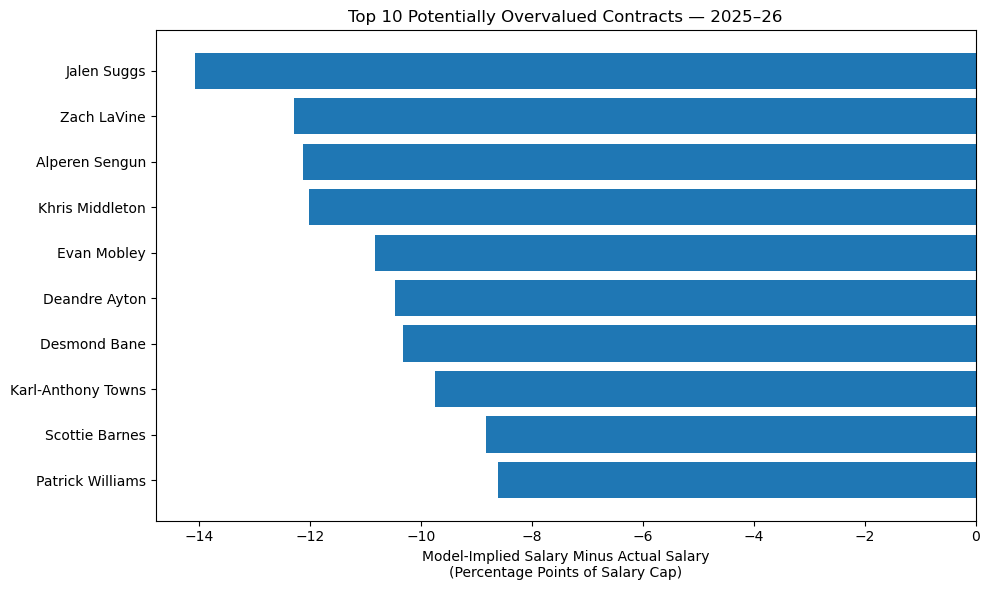

In [54]:
top10_overpaid = (
    qualified
    .nsmallest(10, "value_gap")
    .sort_values("value_gap", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_overpaid["PLAYER_NAME"],
    top10_overpaid["value_gap"] * 100
)

plt.xlabel("Model-Implied Salary Minus Actual Salary\n(Percentage Points of Salary Cap)")
plt.title("Top 10 Potentially Overvalued Contracts — 2025–26")

plt.tight_layout()
plt.show()